<a href="https://colab.research.google.com/github/AKookani/BrickwallCliffordCircuit/blob/main/Toy_MIPTs_with_Qiskit_Stablizers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit ipywidgets
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 77.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=48fffe948a1941959c2c779d0621235c602313c813a641f87e41d6ae7ec5614a
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


# Explanation of Qiskit stablizer

`qiskit.quantum_info.StabilizerState` represents a **stabilizer quantum state** in Qiskit.

A stabilizer state is any quantum state that can be fully described by **Pauli stabilizers** instead of a full statevector. This makes operations on Clifford circuits very efficient.

Typical examples:

* $|0\rangle$
* $|+\rangle$
* Bell states

### Example 1: Create $|0\rangle$ stabilizer

In [2]:
from qiskit.quantum_info import StabilizerState, Statevector, SparsePauliOp

stabilizer_state = StabilizerState.from_stabilizer_list(["Z"]) #returns the state is stabilized by Z operator
print(stabilizer_state)

StabilizerState(['+Z'])


Here, `"Z"` means the state is stabilized by the Pauli (Z) operator:

$Z|0\rangle = |0\rangle$

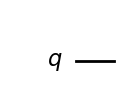

In [3]:
Clifford_circuit = stabilizer_state.clifford.to_circuit()
display(Clifford_circuit.draw('mpl'))

.clifford means What Clifford tableau internally represents this stabilizer state?

In [4]:
psi = Statevector.from_instruction(Clifford_circuit)
display(psi.draw('latex'))


<IPython.core.display.Latex object>

- **`Clifford`** — represents a Clifford *operation* (unitary). Internally it stores a tableau (symplectic matrix + phases) describing how that operation conjugates each Pauli generator. There's no "Clifford state" — `Clifford` is always an operator, never a state.
- **`StabilizerState`** — represents a stabilizer *state*. Internally it stores a `Clifford` object as its underlying data structure, but interprets it as: "the state obtained by applying this Clifford to $|0\rangle^{\otimes n}$." So a `StabilizerState`'s tableau is literally "what Pauli generators does $|0\rangle^{\otimes n}$ get mapped to" — i.e. the stabilizer generators of the resulting state.

In [14]:
psi = Statevector.from_label('0')
print(psi.expectation_value(SparsePauliOp('Z')))

(1+0j)


In [15]:
psi = Statevector.from_label('1')
print(psi.expectation_value(SparsePauliOp('Z')))

(-1+0j)


### Example 2: Bell state

The Bell state

[
$\frac{|00\rangle + |11\rangle}{\sqrt2}$
]

is stabilized by

* (XX)
* (ZZ)

In [ ]:
from qiskit.quantum_info import StabilizerState

bell = StabilizerState.from_stabilizer_list([
    "XX",
    "ZZ"
])

print(bell)

StabilizerState(['+XX', '+ZZ'])


### Example 3: From a Clifford circuit

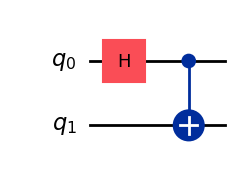

StabilizerState(['+XX', '+ZZ'])


In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import StabilizerState

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
display(qc.draw('mpl'))

state = StabilizerState(qc)
print(state)

### When to use StabilizerState

Use `StabilizerState` when your circuit only contains **Clifford gates**, such as:

* H
* S
* X, Y, Z
* CNOT (CX)
* SWAP

It is **much more memory-efficient** than a full statevector for these circuits.

If your circuit contains non-Clifford gates like `T`, `CCX` (Toffoli, in general), or arbitrary rotations (`RX`, `RY`, `RZ` with arbitrary angles), then `StabilizerState` is generally not applicable, and you'd instead use something like `Statevector`.

# Clifford efficiency

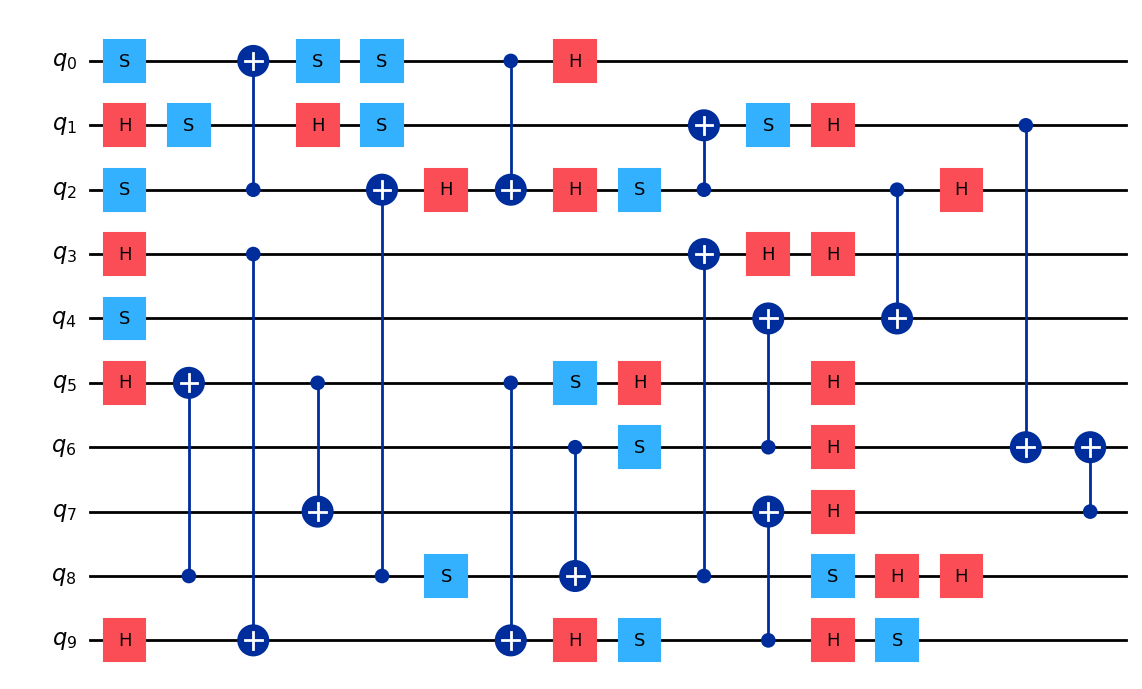

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import StabilizerState
import random

n = 10
qc = QuantumCircuit(n)

for _ in range(50):
    gate = random.choice(["h", "s", "cx"])

    if gate == "h":
        qc.h(random.randrange(n))

    elif gate == "s":
        qc.s(random.randrange(n))

    else:
        a, b = random.sample(range(n), 2)
        qc.cx(a, b)

qc.draw("mpl")

In [ ]:
stab = StabilizerState(qc)

print(stab) #There will be 10 generators because we have 10 qubits.

StabilizerState(['+IZIXIIIXIX', '-IIIXIIIIYI', '+IZIXIIIXII', '+YIIIIIXIII', '+IIIXIZIXII', '+YIZIYIIIII', '+IIIXIIIIII', '+YIXXZIIIII', '+IZIXIIIIII', '+YIIIIIIIII'])


In [ ]:
from qiskit.quantum_info import Statevector

psi = Statevector.from_instruction(qc)

psi.draw('latex')

<IPython.core.display.Latex object>

# Create a stabilizer state with Qiskit

In [ ]:
from qiskit.quantum_info import StabilizerState

# |000>
state = StabilizerState.from_stabilizer_list([
    "+ZII",
    "+IZI",
    "+IIZ"
])

print(state)

StabilizerState(['+ZII', '+IZI', '+IIZ'])


In [ ]:
Clifford_tabeleau = state.clifford
Clifford_tabeleau

Clifford(array([[False, False,  True, False, False, False, False],
       [False,  True, False, False, False, False, False],
       [ True, False, False, False, False, False, False],
       [False, False, False, False, False,  True, False],
       [False, False, False, False,  True, False, False],
       [False, False, False,  True, False, False, False]]))

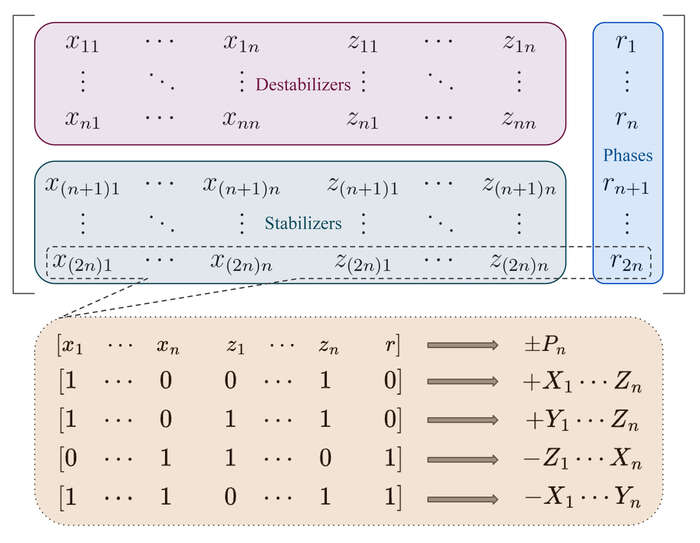

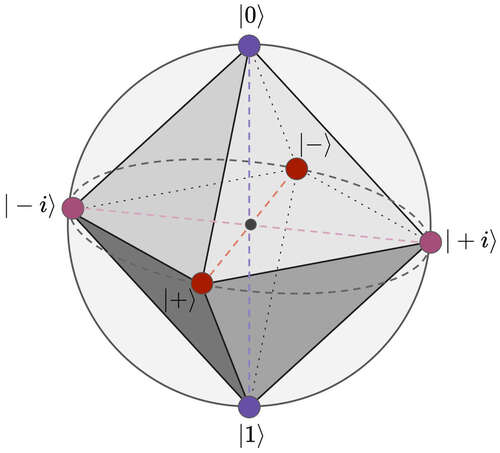

**The octahedron in the Bloch sphere defines the states accessible via single-qubit Clifford gates.**

**To turn the clifford tableau into a state vector, we need a circuit intermediary**

In [ ]:
from qiskit.quantum_info import Statevector

sv = Statevector.from_instruction(Clifford_tabeleau.to_circuit())

sv.draw('latex')

<IPython.core.display.Latex object>

## How to choose a valid Stabilizer List

A **stabilizer group** for a quantum state $|\psi\rangle$ is a set of Pauli operators (or more generally, Clifford operators) that leave the state unchanged when applied. This means for every operator $S$ in the stabilizer group, $S|\psi\rangle = |\psi\rangle$. The state $|\psi\rangle$ is the unique common $+1$ eigenstate of all operators in its stabilizer group.

To construct a valid stabilizer list for `StabilizerState.from_stabilizer_list()`, you need to provide a set of generators for the stabilizer group. These generators must satisfy a few conditions:

1.  **Commutation/Anticommutation:** The generators must either commute or anticommute in a specific way that ensures they uniquely define a state. If two generators $S_i$ and $S_j$ commute ($[S_i, S_j] = 0$), then they can both stabilize the same state. If they anticommute, they cannot both stabilize the same state simultaneously, and this would lead to an invalid stabilizer group (unless they are for different qubits that don't interact or if one is the measurement of another).

2.  **Linear Independence (in terms of Pauli strings):** The set of generators should be linearly independent such that no generator can be expressed as a product of other generators (up to a phase factor). If a stabilizer can be written as a product of other stabilizers, it is redundant.

3.  **Completeness:** For an $n$-qubit system, a complete set of generators for a pure stabilizer state typically consists of $n$ independent and commuting Pauli operators. These $n$ operators, when multiplied together in all possible combinations, should generate a group of $2^n$ distinct operators.

4.  **No Contradictions:** The generators must be consistent. For example, you cannot have both `+ZII` and `-ZII` as generators for the same state, as this would imply a contradiction ($|\psi\rangle = +ZII|\psi\rangle$ and $|\psi\rangle = -ZII|\psi\rangle$, which can only be true for $|\psi\rangle = 0$). The `StabilizerState` constructor generally handles the signs, but it's good to keep in mind.

### Practical Approach:

*   **Start with known stabilizer states:** For common states like $|0\rangle$, $|+\rangle$, Bell states, or GHZ states, the stabilizer generators are well-known (as shown in the examples above).
*   **Derive from circuits:** If you have a Clifford circuit, you can directly create a `StabilizerState` from it, and Qiskit will automatically determine the stabilizer generators (as seen in `state = StabilizerState(qc)`).
*   **Check properties:** If you are proposing a new set of stabilizers, you can test them by trying to create the `StabilizerState` object. Qiskit's `StabilizerState` class will raise an error if the input list is inconsistent or invalid.

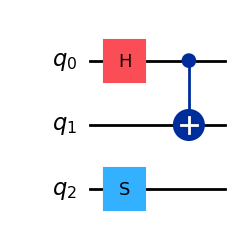

StabilizerState(['+ZII', '+IZZ', '+IXX'])


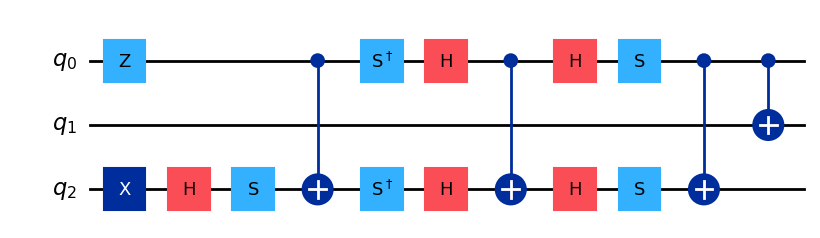

In [ ]:
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import Clifford

qc = QuantumCircuit(3)

qc.h(0)
qc.cx(0,1)
qc.s(2)
display(qc.draw('mpl'))

# Create a Clifford object from the quantum circuit.
cliff = Clifford(qc)

# Evolve the current StabilizerState by applying the Clifford operation.
# This updates the state to reflect the action of the circuit.
state = state.evolve(cliff)

# Print the updated StabilizerState, showing its new stabilizers.
print(state)
qc = state.clifford.to_circuit()
qc.draw("mpl")

In [ ]:
import numpy as np
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import Clifford

rng = np.random.default_rng()

qc = QuantumCircuit(3)

for _ in range(5):

    gate = rng.choice(["H","S","CX"])

    if gate=="H":
        qc.h(rng.integers(3))

    elif gate=="S":
        qc.s(rng.integers(3))

    else:
        q1,q2 = rng.choice(3,2,replace=False)
        qc.cx(q1,q2)

cliff = Clifford(qc)

state = state.evolve(cliff)

In [ ]:
from qiskit.quantum_info import Pauli

P = Pauli("XZI")

print(P)

XZI


In [ ]:
P1 = Pauli("XII")
P2 = Pauli("ZII")

print(P1.anticommutes(P2))

True


In [ ]:
P1.compose(P2)

Pauli('iYII')

In [ ]:
from qiskit.quantum_info import Pauli

observable = Pauli("ZII")

# Is the measurement deterministic?
print(state.expectation_value(observable))

1


In [ ]:
from qiskit.quantum_info import partial_trace
from qiskit.quantum_info import entropy

rho = state.to_operator()

# (For general states we'd convert to a density matrix first.)

In [ ]:
for t in range(T):

    apply_random_clifford()

    for qubit in range(n):

        if rng.random() < p:

            measure_Z(qubit)

    entropy_history.append(entropy())

NameError: name 'T' is not defined